Dataset Size	Linear Time	Binary Time
100		0.000751		0.000044
1000		0.000400		0.000018
10000		0.004534		0.000026
100000		0.042094		0.000030
1000000		0.445074		0.000039


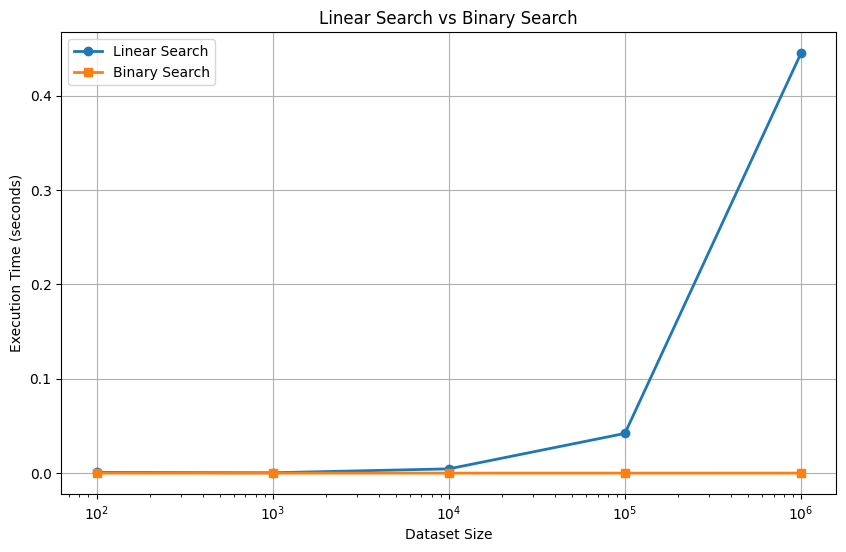

In [2]:
import timeit
import matplotlib.pyplot as plt


# Linear Search
def linear_search(arr, target):
    for i in range(len(arr)):
        if arr[i] == target:
            return i
    return -1


# Binary Search
def binary_search(arr, target):
    low = 0
    high = len(arr) - 1

    while low <= high:
        mid = (low + high) // 2

        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1

    return -1


sizes = [10**2, 10**3, 10**4, 10**5, 10**6]

linear_times = []
binary_times = []

for size in sizes:

    arr = list(range(size))

    target = size - 1

    linear_time = timeit.timeit(
        lambda: linear_search(arr, target),
        number=10
    )

    binary_time = timeit.timeit(
        lambda: binary_search(arr, target),
        number=10
    )

    linear_times.append(linear_time)
    binary_times.append(binary_time)

print("Dataset Size\tLinear Time\tBinary Time")

for s, l, b in zip(sizes, linear_times, binary_times):
    print(f"{s}\t\t{l:.6f}\t\t{b:.6f}")

plt.figure(figsize=(10,6))

plt.plot(sizes, linear_times, marker='o', linewidth=2, label='Linear Search')
plt.plot(sizes, binary_times, marker='s', linewidth=2, label='Binary Search')

plt.xscale('log')

plt.xlabel("Dataset Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Linear Search vs Binary Search")

plt.grid(True)
plt.legend()

plt.show()